# 03 · What Drives Price?

**Question:** which listing characteristics are associated with higher nightly prices in Amsterdam, and by how much?

This notebook looks at one driver at a time (bivariate). Where a comparison might be confounded by room type (private rooms are smaller, cheaper and differ in amenities), we repeat it **within entire homes only**. Controlled, multi-variable estimates come in `05_modelling.ipynb`.

Percentage premiums compare **medians**, which are robust to the long price tail.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.style import (BLUE, DATA_PROCESSED, DIVERGING, NEUTRAL, ORANGE, SURFACE, TEXT_SECONDARY,
                       euro, save_fig, set_style)

set_style()
np.random.seed(42)  # makes the jitter in the size scatter plots reproducible
df = pd.read_csv(DATA_PROCESSED / "listings_clean.csv")
homes = df[df["room_type"] == "Entire home/apt"]
print(f"{len(df):,} listings ({len(homes):,} entire homes)")


def premium(a, b):
    """% by which the median of a exceeds the median of b."""
    return (np.median(a) / np.median(b) - 1) * 100

6,086 listings (4,682 entire homes)


## 1. Correlation heatmap

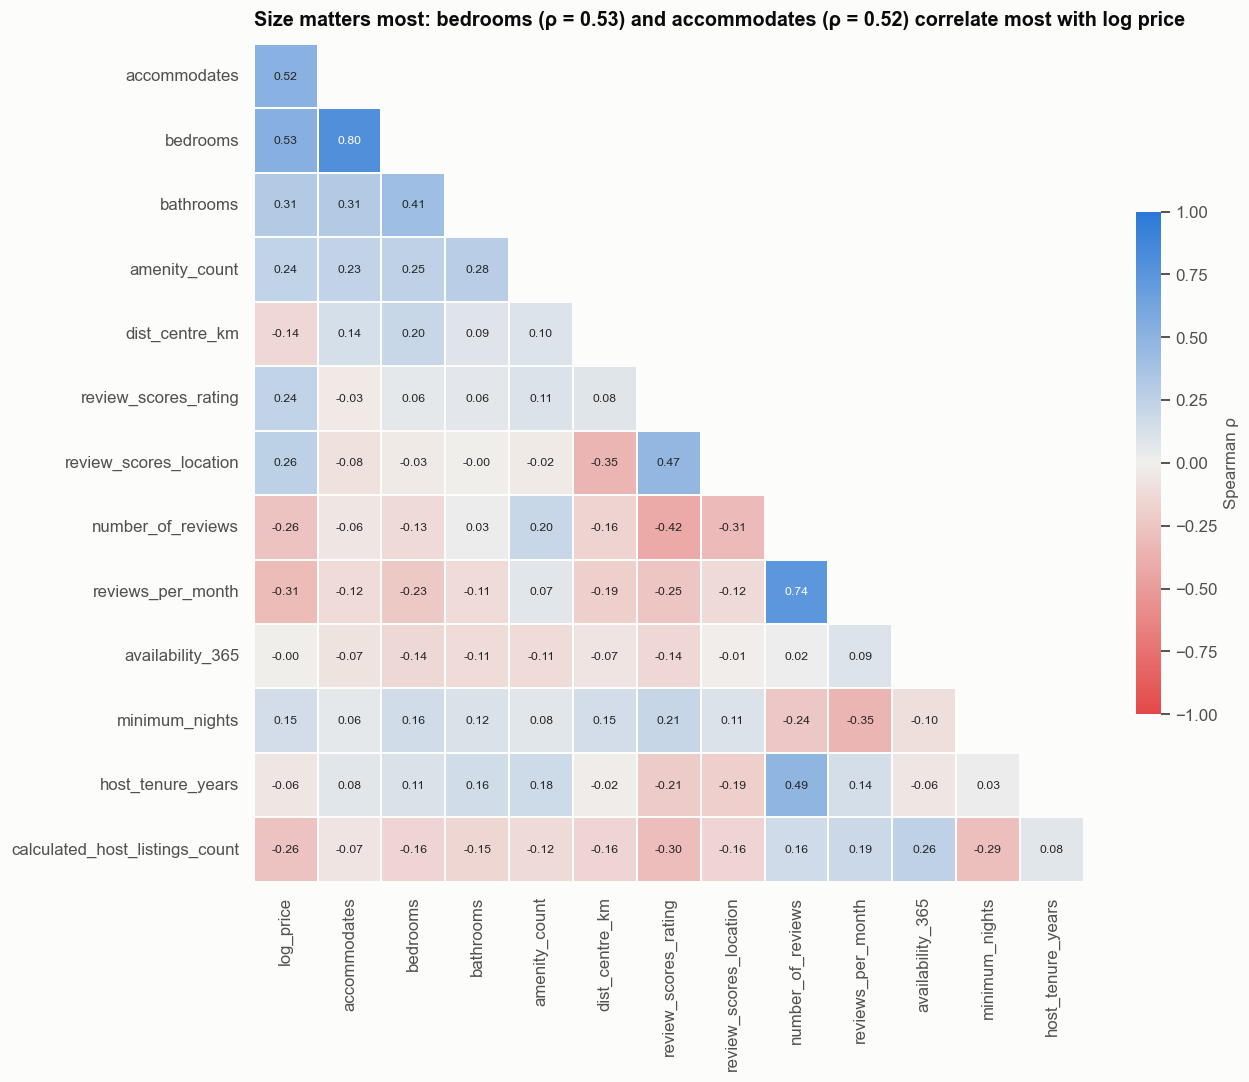

In [2]:
num_cols = ["log_price", "accommodates", "bedrooms", "bathrooms", "amenity_count",
            "dist_centre_km", "review_scores_rating", "review_scores_location", "number_of_reviews",
            "reviews_per_month", "availability_365", "minimum_nights", "host_tenure_years",
            "calculated_host_listings_count"]
corr = df[num_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr.iloc[1:, :-1], mask=mask[1:, :-1], cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=1, linecolor=SURFACE, cbar_kws={"shrink": 0.6, "label": "Spearman ρ"}, ax=ax)
ax.grid(False)
top = corr["log_price"].drop("log_price").abs().sort_values(ascending=False)
ax.set_title(f"Size matters most: {top.index[0]} (ρ = {corr.loc['log_price', top.index[0]]:.2f}) and "
             f"{top.index[1]} (ρ = {corr.loc['log_price', top.index[1]]:.2f}) correlate most with log price")
plt.tight_layout()
save_fig(fig, "03_correlation_heatmap")
plt.show()

Spearman (rank) correlation is used because several features are skewed or ordinal. Correlation with `log_price`:

In [3]:
corr["log_price"].drop("log_price").sort_values(ascending=False).round(2).to_frame("ρ with log price")

,ρ with log price
bedrooms,0.53
accommodates,0.52
bathrooms,0.31
review_scores_location,0.26
review_scores_rating,0.24
amenity_count,0.24
minimum_nights,0.15
availability_365,-0.00
host_tenure_years,-0.06
dist_centre_km,-0.14


## 2. Size: accommodates and bedrooms
A straight line fitted to **log price** gives a constant % effect per unit: premium = e^slope − 1.

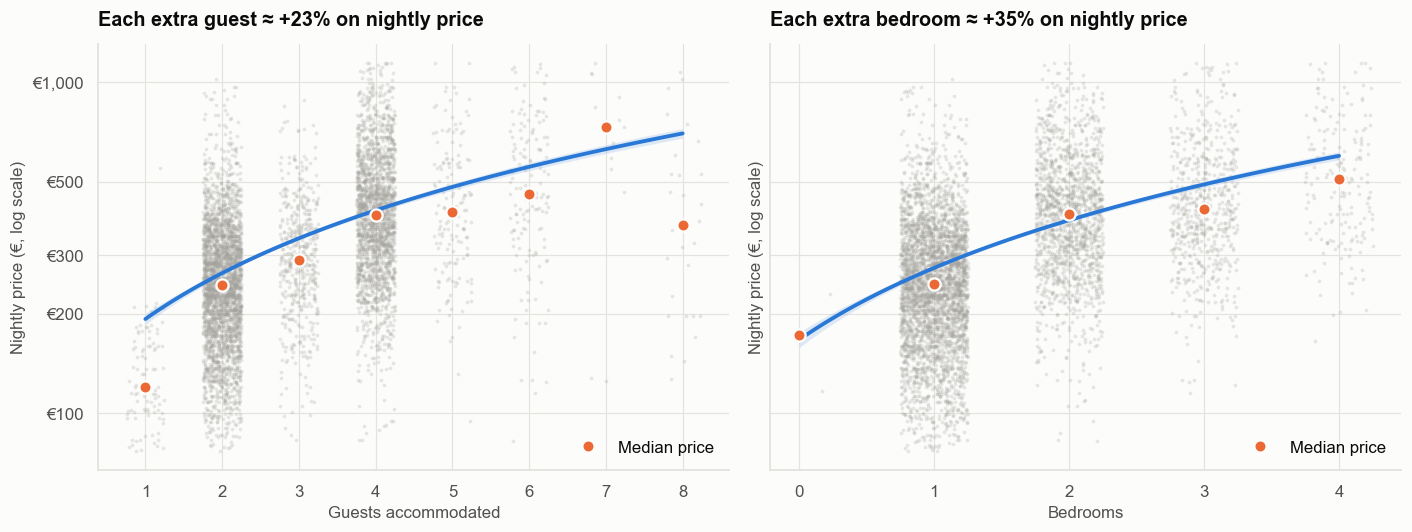

In [4]:
def log_slope_pct(x, y_log):
    slope = np.polyfit(x, y_log, 1)[0]
    return (np.exp(slope) - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
results = {}
for ax, col, label, cap in [(axes[0], "accommodates", "Guests accommodated", 8),
                            (axes[1], "bedrooms", "Bedrooms", 4)]:
    sub = df[df[col] <= cap]
    pct = log_slope_pct(sub[col], sub["log_price"])
    results[col] = pct
    sns.regplot(data=sub, x=col, y="price", x_jitter=0.25, logx=False, order=1, seed=42, ax=ax,
                scatter_kws={"s": 6, "alpha": 0.25, "color": NEUTRAL, "linewidths": 0},
                line_kws={"color": BLUE, "lw": 2.5}, x_estimator=None)
    meds = sub.groupby(col)["price"].median()
    ax.plot(meds.index, meds.values, "o", color=ORANGE, ms=8, mec=SURFACE, mew=1.5, label="Median price", zorder=5)
    ax.set_yscale("log")
    ax.set_yticks([100, 200, 300, 500, 1000])
    ax.yaxis.set_major_formatter(euro)
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.set(xlabel=label, ylabel="Nightly price (€, log scale)",
           title=f"Each extra {'guest' if col == 'accommodates' else 'bedroom'} ≈ +{pct:.0f}% on nightly price")
    ax.legend(loc="lower right")
plt.tight_layout()
save_fig(fig, "03_price_vs_size")
plt.show()

In [5]:
for col, cap in [("accommodates", 8), ("bedrooms", 4)]:
    print(df[df[col] <= cap].groupby(col)["price"].agg(["size", "median"]).round(0).T.to_string(), "\n")

accommodates      1       2      3       4      5      6      7      8
size           94.0  3082.0  481.0  2065.0  150.0  153.0   13.0   28.0
median        120.0   245.0  291.0   397.0  406.0  460.0  733.0  370.0 

bedrooms    0.0     1.0     2.0    3.0    4.0
size        2.0  3711.0  1538.0  627.0  185.0
median    173.0   246.0   400.0  413.0  510.0 



Listings with more than 8 guests or 4 bedrooms are excluded from the fitted line (few listings, unstable), but kept in the dataset.

## 3. Superhosts vs regular hosts
Mann-Whitney U tests (two-sided) compare the distributions without assuming normality. Effect size is the rank-biserial correlation *r* (0 = no difference, ±1 = complete separation).

In [6]:
def mann_whitney(a, b):
    a, b = pd.Series(a).dropna(), pd.Series(b).dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    r = 1 - 2 * u / (len(a) * len(b))  # rank-biserial (positive = a tends to be larger)
    return {"median_superhost": a.median(), "median_regular": b.median(), "n_superhost": len(a), "n_regular": len(b),
            "U": u, "p_value": p, "rank_biserial_r": -r}

rows = {}
for scope, frame in [("All listings", df), ("Entire homes only", homes)]:
    sh, rg = frame[frame["host_is_superhost"]], frame[~frame["host_is_superhost"]]
    for metric in ["price", "review_scores_rating", "number_of_reviews"]:
        rows[(scope, metric)] = mann_whitney(sh[metric], rg[metric])
sh_tests = pd.DataFrame(rows).T
sh_tests["premium_%"] = (sh_tests["median_superhost"] / sh_tests["median_regular"] - 1) * 100
sh_tests.style.format({"median_superhost": "{:.2f}", "median_regular": "{:.2f}", "n_superhost": "{:.0f}",
                       "n_regular": "{:.0f}", "U": "{:,.0f}", "p_value": "{:.2e}", "rank_biserial_r": "{:.3f}",
                       "premium_%": "{:+.1f}"})

Superhost share: 23.5% of listings


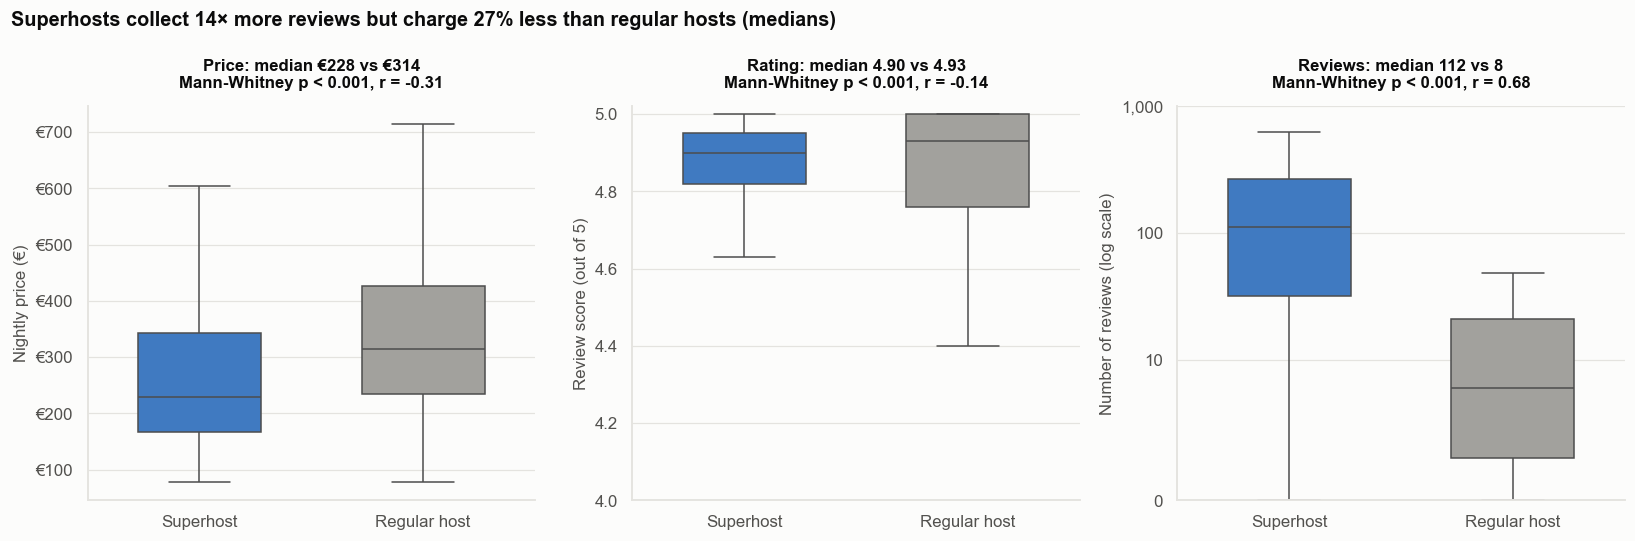

In [7]:
print(f"Superhost share: {df['host_is_superhost'].mean():.1%} of listings")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot = df.assign(host_type=np.where(df["host_is_superhost"], "Superhost", "Regular host"))
order = ["Superhost", "Regular host"]
colors = {"Superhost": BLUE, "Regular host": NEUTRAL}
specs = [("price", "Nightly price (€)", None), ("review_scores_rating", "Review score (out of 5)", (4.0, 5.02)),
         ("number_of_reviews", "Number of reviews (log scale)", None)]
names = {"price": "Price", "review_scores_rating": "Rating", "number_of_reviews": "Reviews"}
fmts = {"price": "€{:,.0f}", "review_scores_rating": "{:.2f}", "number_of_reviews": "{:,.0f}"}
for ax, (metric, label, ylim) in zip(axes, specs):
    sns.boxplot(data=plot, x="host_type", y=metric, order=order, hue="host_type", palette=colors, legend=False,
                showfliers=False, width=0.55, linewidth=1, ax=ax)
    res = sh_tests.loc[("All listings", metric)]
    p_txt = "p < 0.001" if res["p_value"] < 0.001 else f"p = {res['p_value']:.3f}"
    f = fmts[metric]
    ax.set_title(f"{names[metric]}: median {f.format(res['median_superhost'])} vs {f.format(res['median_regular'])}\n"
                 f"Mann-Whitney {p_txt}, r = {res['rank_biserial_r']:.2f}",
                 fontsize=11, loc="center")
    ax.set(xlabel="", ylabel=label)
    if ylim:
        ax.set_ylim(*ylim)
    if metric == "number_of_reviews":
        ax.set_yscale("symlog", linthresh=10)
        ax.set_ylim(0, None)
        ax.set_yticks([0, 10, 100, 1000])
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    if metric == "price":
        ax.yaxis.set_major_formatter(euro)
rev_ratio = sh_tests.loc[("All listings", "number_of_reviews"), "median_superhost"] / sh_tests.loc[("All listings", "number_of_reviews"), "median_regular"]
fig.suptitle(f"Superhosts collect {rev_ratio:.0f}× more reviews but charge "
             f"{abs(sh_tests.loc[('All listings', 'price'), 'premium_%']):.0f}% less than regular hosts (medians)",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "03_superhost_comparison")
plt.show()

**Why are superhosts cheaper?** Superhost status is earned through volume (bookings, reviews), and volume is easier with cheaper private rooms. The room-type mix differs sharply:

In [8]:
mix = pd.crosstab(np.where(df["host_is_superhost"], "Superhost", "Regular host"), df["room_type"], normalize="index").mul(100).round(1)
mix

room_type,Entire home/apt,Hotel room,Private room,Shared room
row_0,,,,
Regular host,85.6,0.4,14.0,0.0
Superhost,48.5,0.4,51.0,0.1


- About half of superhost listings are private rooms, against roughly one in seven for regular hosts. Within **entire homes only**, the price gap shrinks to a few percent (table above), with a small effect size.
- Regular hosts' slightly *higher* median rating is partly a small-sample effect: their median listing has only 8 reviews, so a handful of 5-star reviews gives a perfect score.
- **Conclusion:** superhost status signals *volume and reliability*, not a licence to charge more. The model in notebook 05 tests this while controlling for room type and size.

## 4. Amenities and review scores

In [9]:
amen_bins = pd.cut(homes["amenity_count"], [-1, 15, 25, 35, 45, 60, 200], labels=["0–15", "16–25", "26–35", "36–45", "46–60", "60+"])
amen_tbl = homes.groupby(amen_bins, observed=True)["price"].agg(listings="size", median_price="median")

reviewed = homes[homes["has_reviews"]]
score_bins = pd.cut(reviewed["review_scores_rating"], [0, 4.5, 4.7, 4.8, 4.9, 4.95, 5.0],
                    labels=["≤4.50", "4.51–4.70", "4.71–4.80", "4.81–4.90", "4.91–4.95", "4.96–5.00"])
score_tbl = reviewed.groupby(score_bins, observed=True)["price"].agg(listings="size", median_price="median")
display(amen_tbl.round(0), score_tbl.round(0))

,listings,median_price
amenity_count,,
0–15,650,305.0
16–25,682,306.0
26–35,1049,306.0
36–45,1147,331.0
46–60,947,389.0
60+,207,450.0


,listings,median_price
review_scores_rating,,
≤4.50,231,285.0
4.51–4.70,345,287.0
4.71–4.80,412,303.0
4.81–4.90,778,342.0
4.91–4.95,461,353.0
4.96–5.00,1995,338.0


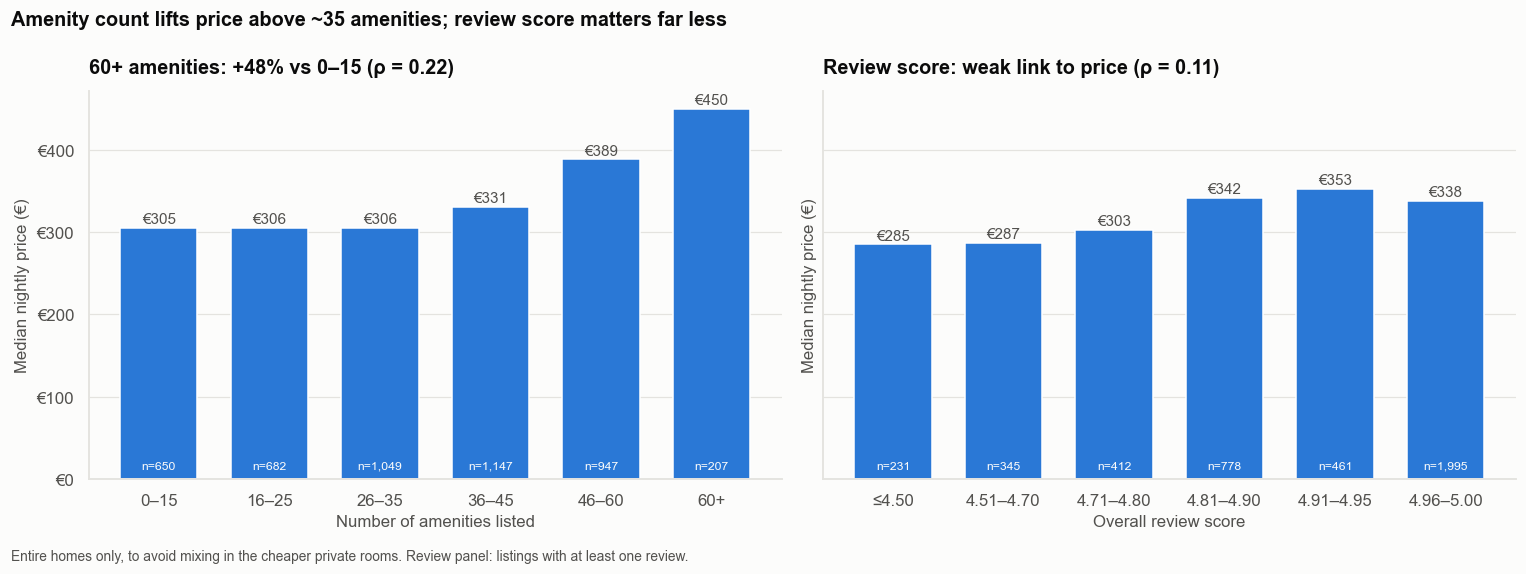

In [10]:
rho_amen, p_amen = stats.spearmanr(homes["amenity_count"], homes["price"])
rho_score, p_score = stats.spearmanr(reviewed["review_scores_rating"], reviewed["price"])
amen_gap = amen_tbl["median_price"].iloc[-1] / amen_tbl["median_price"].iloc[0] - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, tbl, xlabel, title in [
    (axes[0], amen_tbl, "Number of amenities listed",
     f"60+ amenities: {amen_gap:+.0%} vs 0–15 (ρ = {rho_amen:.2f})"),
    (axes[1], score_tbl, "Overall review score",
     f"Review score: weak link to price (ρ = {rho_score:.2f})"),
]:
    bars = ax.bar(tbl.index.astype(str), tbl["median_price"], color=BLUE, width=0.7)
    for b, (m, n) in zip(bars, tbl[["median_price", "listings"]].values):
        ax.text(b.get_x() + b.get_width() / 2, m + 6, f"€{m:,.0f}", ha="center", fontsize=10, color=TEXT_SECONDARY)
        ax.text(b.get_x() + b.get_width() / 2, 12, f"n={n:,.0f}", ha="center", fontsize=8, color=SURFACE)
    ax.yaxis.set_major_formatter(euro)
    ax.set(xlabel=xlabel, ylabel="Median nightly price (€)", title=title)
    ax.grid(axis="x", visible=False)
fig.suptitle("Amenity count lifts price above ~35 amenities; review score matters far less",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.text(0.01, -0.02, "Entire homes only, to avoid mixing in the cheaper private rooms. Review panel: listings with at least one review.",
         color=TEXT_SECONDARY, fontsize=9)
plt.tight_layout()
save_fig(fig, "03_amenities_reviews_vs_price")
plt.show()

### Which individual amenities carry a premium? (entire homes)

In [11]:
amen_cols = [c for c in df.columns if c.startswith("amen_")]
amen_prem = pd.DataFrame({
    col.replace("amen_", "").replace("_", " "): {
        "% of homes with it": homes[col].mean() * 100,
        "median with": homes.loc[homes[col], "price"].median(),
        "median without": homes.loc[~homes[col], "price"].median(),
        "premium %": premium(homes.loc[homes[col], "price"], homes.loc[~homes[col], "price"]),
        "p_value": stats.mannwhitneyu(homes.loc[homes[col], "price"], homes.loc[~homes[col], "price"]).pvalue,
    } for col in amen_cols if 0.03 < homes[col].mean() < 0.97
}).T.sort_values("premium %", ascending=False)
amen_prem.style.format({"% of homes with it": "{:.1f}", "median with": "€{:.0f}", "median without": "€{:.0f}",
                        "premium %": "{:+.1f}", "p_value": "{:.1e}"})

,% of homes with it,median with,median without,premium %,p_value
washer,91.2,€341,€237,+43.8,3.3e-51
kitchen,95.9,€336,€248,+35.8,7.2e-22
bathtub,32.2,€387,€305,+27.0,3.4e-79
dishwasher,66.9,€350,€286,+22.6,7.4e-48
air conditioning,14.8,€385,€323,+19.0,2.4e-17
waterfront,16.3,€362,€326,+11.1,1.6e-06
balcony,44.9,€349,€317,+10.1,6.0e-15
workspace,58.0,€344,€314,+9.7,2.1e-13
free parking,7.0,€337,€331,+1.8,9.3e-01
self checkin,31.7,€328,€333,-1.4,1.3e-01


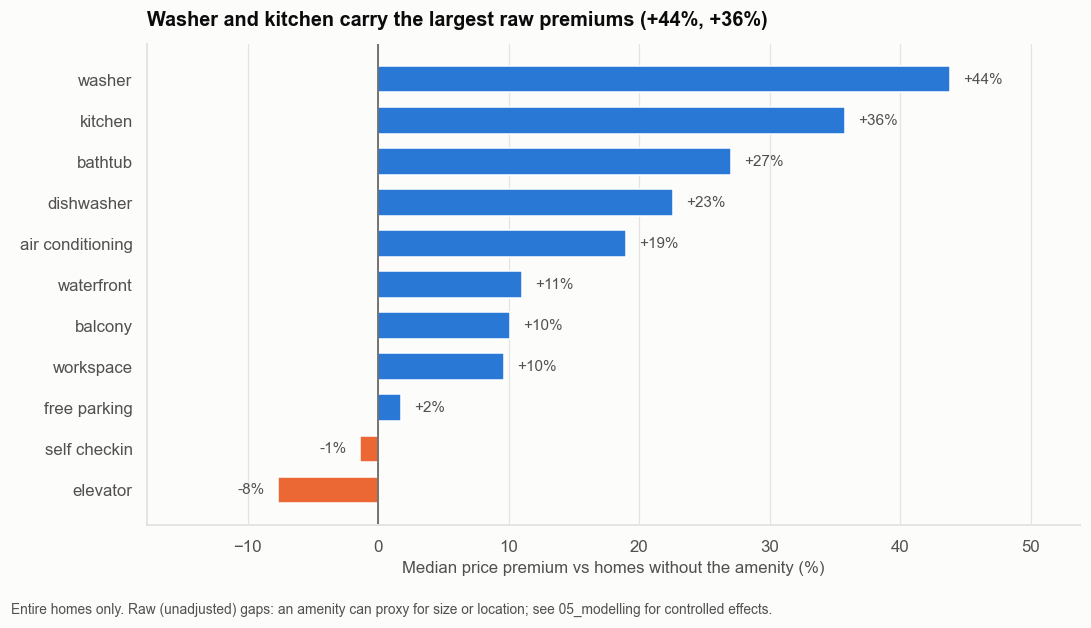

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))
vals = amen_prem["premium %"].sort_values()
ax.barh(vals.index, vals.values, color=[BLUE if v > 0 else ORANGE for v in vals.values], height=0.65)
for i, v in enumerate(vals.values):
    ax.text(v + (1 if v >= 0 else -1), i, f"{v:+.0f}%", va="center", ha="left" if v >= 0 else "right",
            fontsize=10, color=TEXT_SECONDARY)
ax.axvline(0, color=TEXT_SECONDARY, lw=1)
ax.set_xlim(vals.min() - 10, vals.max() + 10)
ax.set(title=f"{vals.index[-1].capitalize()} and {vals.index[-2]} carry the largest raw premiums ({vals.iloc[-1]:+.0f}%, {vals.iloc[-2]:+.0f}%)",
       xlabel="Median price premium vs homes without the amenity (%)", ylabel="")
ax.grid(axis="y", visible=False)
fig.text(0.01, -0.03, "Entire homes only. Raw (unadjusted) gaps: an amenity can proxy for size or location; see 05_modelling for controlled effects.",
         color=TEXT_SECONDARY, fontsize=9)
plt.tight_layout()
save_fig(fig, "03_amenity_premiums")
plt.show()

## 5. Summary: headline premiums

In [13]:
private = df[df["room_type"] == "Private room"]
central, outer = df[df["dist_centre_km"] < 3], df[df["dist_centre_km"] >= 5]
summary = pd.DataFrame([
    ("Entire home vs private room", premium(homes["price"], private["price"])),
    ("Within 3 km of Dam Square vs 5+ km", premium(central["price"], outer["price"])),
    ("Entire homes: within 3 km vs 5+ km",
     premium(homes.loc[homes["dist_centre_km"] < 3, "price"], homes.loc[homes["dist_centre_km"] >= 5, "price"])),
    ("Each extra guest (log-linear fit, ≤8 guests)", results["accommodates"]),
    ("Each extra bedroom (log-linear fit, ≤4 bedrooms)", results["bedrooms"]),
    ("Entire homes: 2 bedrooms vs 1", premium(homes.loc[homes["bedrooms"] == 2, "price"], homes.loc[homes["bedrooms"] == 1, "price"])),
    ("Superhost vs regular host (all)", sh_tests.loc[("All listings", "price"), "premium_%"]),
    ("Superhost vs regular host (entire homes)", sh_tests.loc[("Entire homes only", "price"), "premium_%"]),
    ("Entire homes: 46+ amenities vs ≤25", premium(homes.loc[homes["amenity_count"] > 45, "price"], homes.loc[homes["amenity_count"] <= 25, "price"])),
    ("Multi-listing host vs single-listing host", premium(df.loc[df["is_multi_host"], "price"], df.loc[~df["is_multi_host"], "price"])),
], columns=["Comparison", "Median price premium %"]).set_index("Comparison").round(1)
summary

,Median price premium %
Comparison,
Entire home vs private room,84.8
Within 3 km of Dam Square vs 5+ km,46.7
Entire homes: within 3 km vs 5+ km,27.6
"Each extra guest (log-linear fit, ≤8 guests)",23.0
"Each extra bedroom (log-linear fit, ≤4 bedrooms)",35.4
Entire homes: 2 bedrooms vs 1,48.0
Superhost vs regular host (all),-27.2
Superhost vs regular host (entire homes),-6.1
Entire homes: 46+ amenities vs ≤25,31.9


## Key Takeaways

- **Size is the strongest single driver.** Bedrooms (ρ = 0.53) and guest capacity (ρ = 0.52) have the highest rank correlation with log price. Each extra guest is associated with **~23%** higher price and each extra bedroom with **~35%**; among entire homes, 2-bedroom listings cost **48%** more than 1-bedroom ones (median).
- **Room type:** entire homes cost **85%** more than private rooms (median €331 vs €179).
- **Location:** listings within 3 km of Dam Square cost **47%** more than those 5+ km out; within entire homes alone the gap is **28%**.
- **Superhosts charge less, not more:** superhosts' median price is **27% lower** (€228 vs €314, Mann-Whitney p < 0.001, r = −0.31) while they collect **14× more reviews** (112 vs 8). The main reason is the mix: 51% of superhost listings are private rooms vs 14% for regular hosts. Within entire homes the gap shrinks to −6% (r = −0.09). Regular hosts' median rating is marginally higher (4.93 vs 4.90), with a small effect size (r = −0.14).
- **Amenities matter more than ratings:** entire homes with 60+ amenities have a median **48%** above those with 0–15 (ρ = 0.22). Raw premiums are largest for a washer (+44%), kitchen (+36%), bathtub (+27%), dishwasher (+23%) and air conditioning (+19%). Review score has only a weak link to price within entire homes (ρ = 0.11): ≤4.50 → €285, 4.91–4.95 → €353.
- **Caveat:** these are one-at-a-time comparisons. Amenities like a washer partly proxy for larger, fully equipped homes, so notebook 05 estimates effects while holding size, location and room type constant.